In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataframe_exercicio_modulo_8.csv")
df.head()

,ind_pop_cid,perc_pol,taxa_crim,nivel_ed,crimes
0,1.0,7.185471,62.082693,10.0,77
1,1.0,24.456750,88.244380,6.0,202
2,1.0,19.791772,94.930257,1.0,348
3,4.0,10.089496,41.791507,6.0,114
4,3.0,34.697495,67.615795,1.0,47


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
[df_train,df_test] = train_test_split(df, test_size=0.3)

eu escolhi a variavel 'taxa_crim' pq olhando para as outras não me parecer que tem muita semelhança com o resutado que quero ter no final

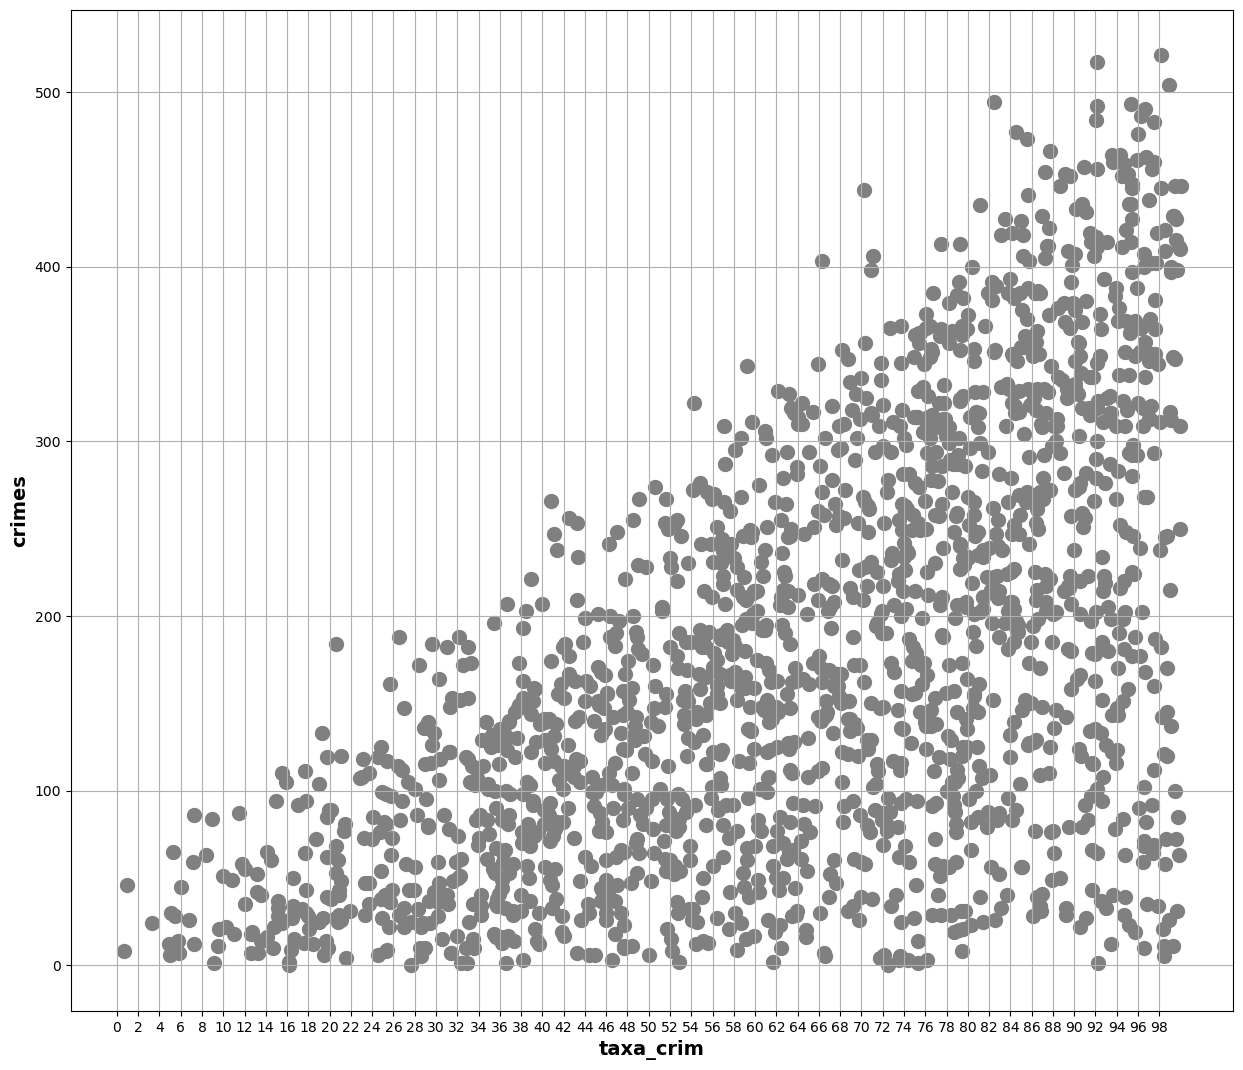

In [5]:
plt.figure(figsize=[15,13])
plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
plt.xlabel("taxa_crim", fontweight = 'bold', fontsize = 14)
plt.ylabel("crimes", fontweight = 'bold', fontsize = 14)
plt.xticks(range(0,100,2))
plt.grid()
plt.show()

In [6]:
def funcao_linear(x, theta0, theta1):
    pred = theta0 + theta1 * x
    pred.name = None
    return pred

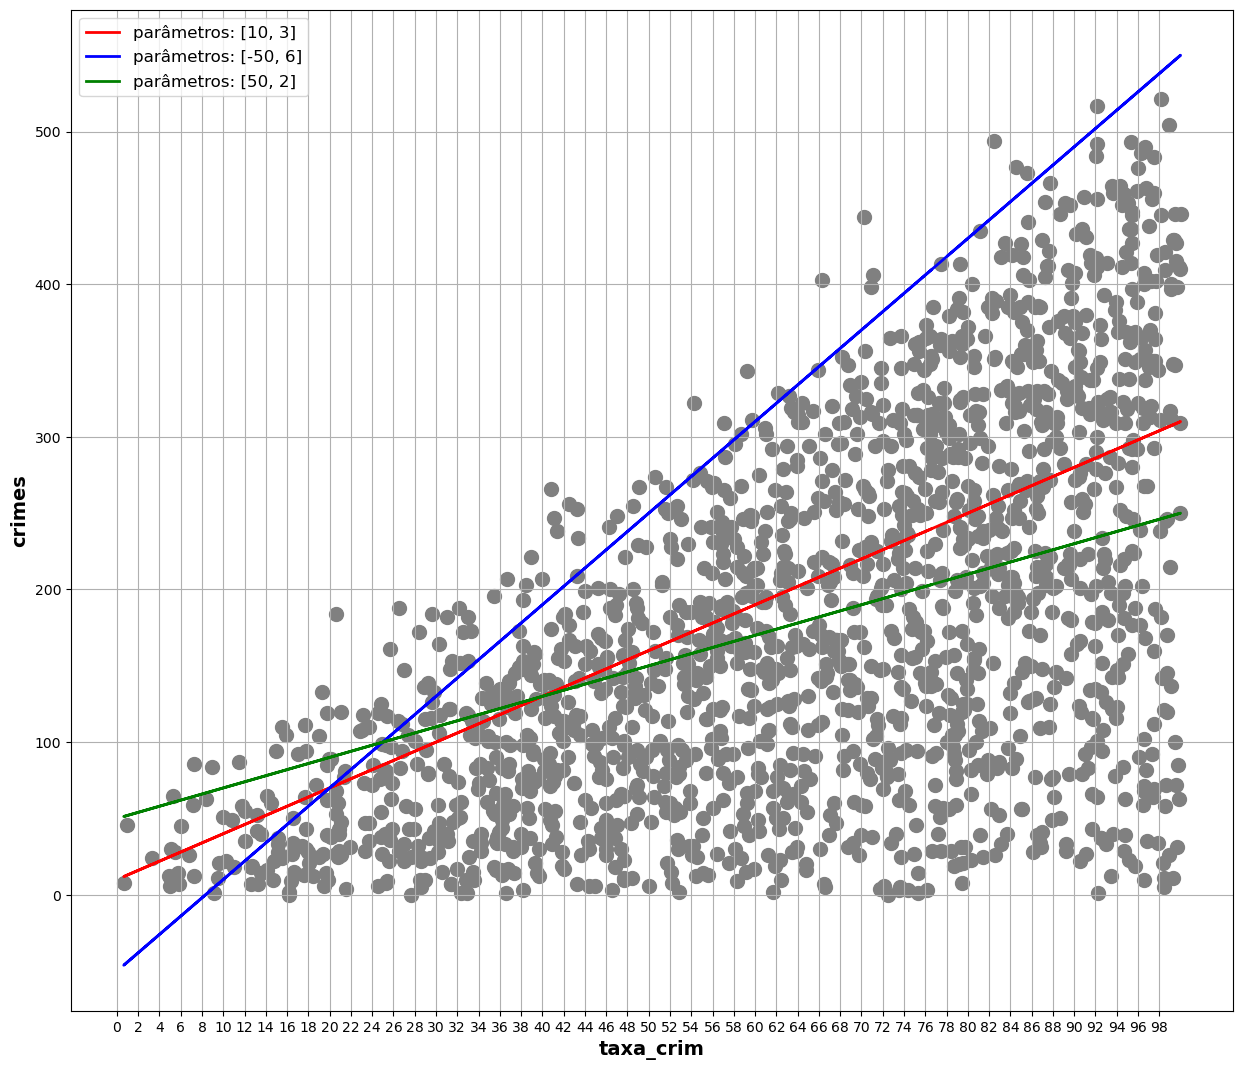

In [7]:
X = df_train['taxa_crim']
y1 = funcao_linear(X, theta0 = 10, theta1 = 3)  
y2 = funcao_linear(X, theta0 = -50, theta1 = 6) 
y3 = funcao_linear(X, theta0 = 50, theta1 = 2) 


plt.figure(figsize=[15,13])
plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
plt.xlabel("taxa_crim", fontweight = 'bold', fontsize = 14)
plt.ylabel("crimes", fontweight = 'bold', fontsize = 14)
plt.xticks(range(0,100,2))
plt.grid()


plt.plot(X, y1, label = 'parâmetros: [10, 3]', lw = 2, c = 'red')
plt.plot(X, y2, label = 'parâmetros: [-50, 6]', lw = 2, c = 'blue')
plt.plot(X, y3, label = 'parâmetros: [50, 2]', lw = 2, c = 'green')
plt.legend(fontsize = 12)
plt.show()

In [8]:
X = df_train['taxa_crim']

In [9]:
y = df_train['crimes']

In [10]:
y_pred = funcao_linear(X, theta0= -50, theta1=6)
y_pred

1920    418.838146
1116    527.938948
724     427.667533
1772    411.670612
2166    405.756276
           ...    
2288    409.684950
364     273.194269
1143    198.264362
969     485.647593
1412    409.028006
Length: 1722, dtype: float64

In [11]:
def MSE(y, y_pred):
    return np.mean((y - y_pred)**2)

def RMSE(y, y_pred):
    return np.sqrt(np.mean((y - y_pred)**2))

In [12]:
y1 = funcao_linear(X, theta0 = 10, theta1 = 3)
y2 = funcao_linear(X, theta0 = -50, theta1 = 6)
y3 = funcao_linear(X, theta0 = 50, theta1 = 2)

RMSE_1 = RMSE(y = df_train['crimes'], y_pred = y1)
RMSE_2 = RMSE(y = df_train['crimes'], y_pred = y2)
RMSE_3 = RMSE(y = df_train['crimes'], y_pred = y3)

print("Os respectivos RMSE de cada modelo são: ")
print('Modelo 1: ', RMSE_1)
print('Modelo 2: ', RMSE_2)
print('Modelo 3: ', RMSE_3)

Os respectivos RMSE de cada modelo são: 
Modelo 1:  101.07804237276274
Modelo 2:  200.2550001828337
Modelo 3:  100.11216531964692


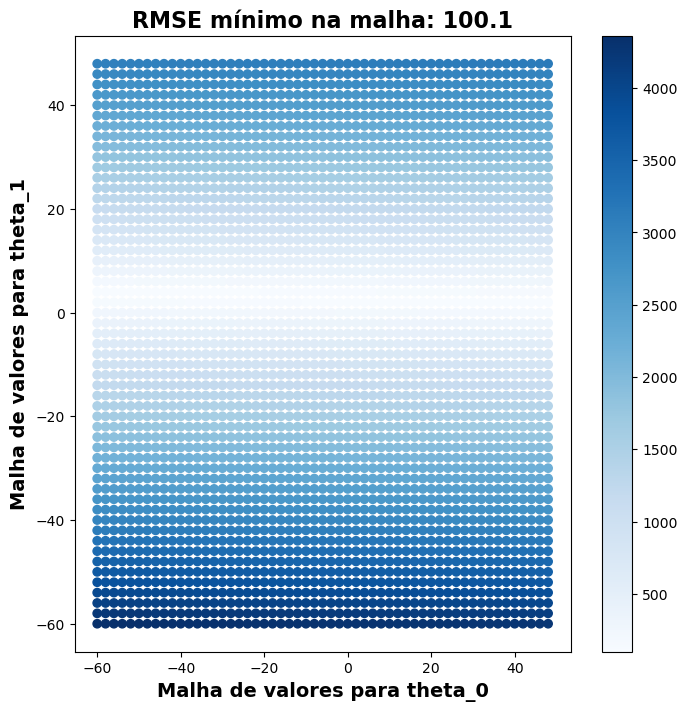

In [13]:
thetas0 = np.arange(-60,50,2)
thetas1 = np.arange(-60,50,2)

grid0, grid1 = np.meshgrid(thetas0, thetas1)
grid0 = np.ravel(grid0)
grid1 = np.ravel(grid1)

X = df_train['taxa_crim']
y = df_train['crimes']

RMSE_list = [RMSE(y = y, y_pred = funcao_linear(x = X, theta0 = t[0], theta1 = t[1])) for t in zip(grid0, grid1)]

RMSE_min = np.min(RMSE_list)

plt.figure(figsize=[8,8])
plt.title("RMSE mínimo na malha: " + str(np.round(RMSE_min,2)), fontweight = 'bold', fontsize = 16)
plt.scatter(grid0, grid1, c = RMSE_list, cmap = plt.cm.Blues)
plt.xlabel("Malha de valores para theta_0", fontweight = 'bold', fontsize = 14)
plt.ylabel("Malha de valores para theta_1", fontweight = 'bold', fontsize = 14)
plt.colorbar()
plt.show()

In [14]:
  from sklearn.linear_model import LinearRegression

In [15]:
lm =  LinearRegression()
lm

LinearRegression()

In [16]:
type(X), type(y)

(pandas.core.series.Series, pandas.core.series.Series)

In [17]:
X = X.values.reshape(-1,1)
type(X), X.shape

(numpy.ndarray, (1722, 1))

In [18]:
y = y.values.reshape(-1,1)
type(y), y.shape

(numpy.ndarray, (1722, 1))

In [19]:
lm.fit(X,y)

LinearRegression()

In [20]:
ypred = lm.predict(X)
ypred

array([[217.44551111],
       [270.79090659],
       [221.76268491],
       ...,
       [109.59482982],
       [250.1123321 ],
       [212.64879291]])

In [21]:
RMSE(y = y, y_pred = ypred)

97.64797634882177

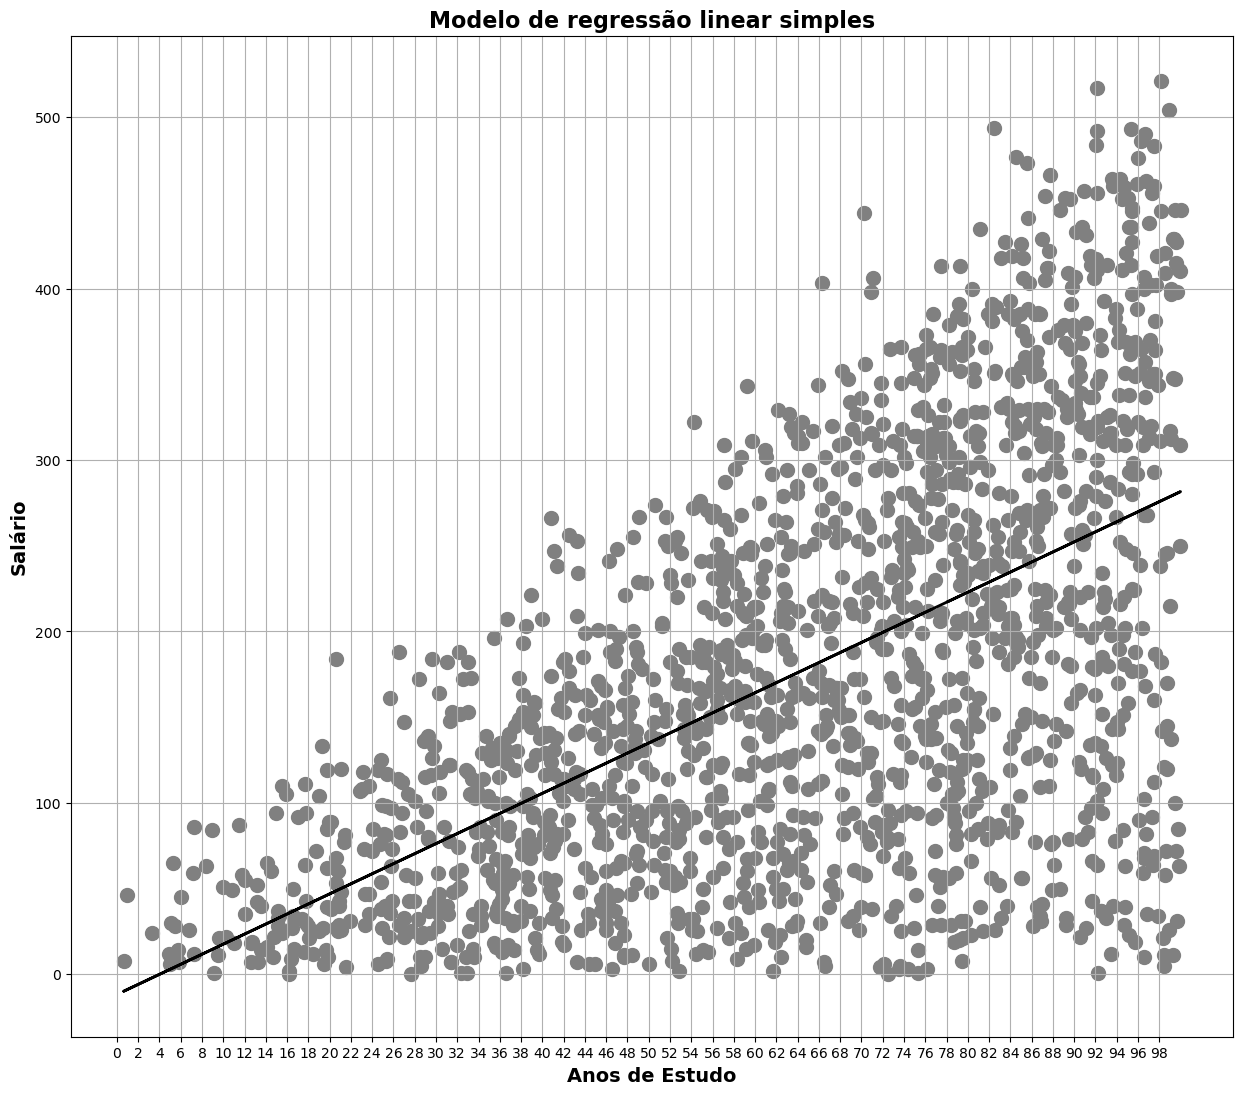

In [22]:
plt.figure(figsize=[15,13])
plt.title("Modelo de regressão linear simples", fontweight = 'bold', fontsize = 16)
plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
plt.xlabel("Anos de Estudo", fontweight = 'bold', fontsize = 14)
plt.ylabel("Salário", fontweight = 'bold', fontsize = 14)
plt.xticks(range(0,100,2))

plt.plot(X, ypred, c = 'black', lw = 2)
plt.grid()

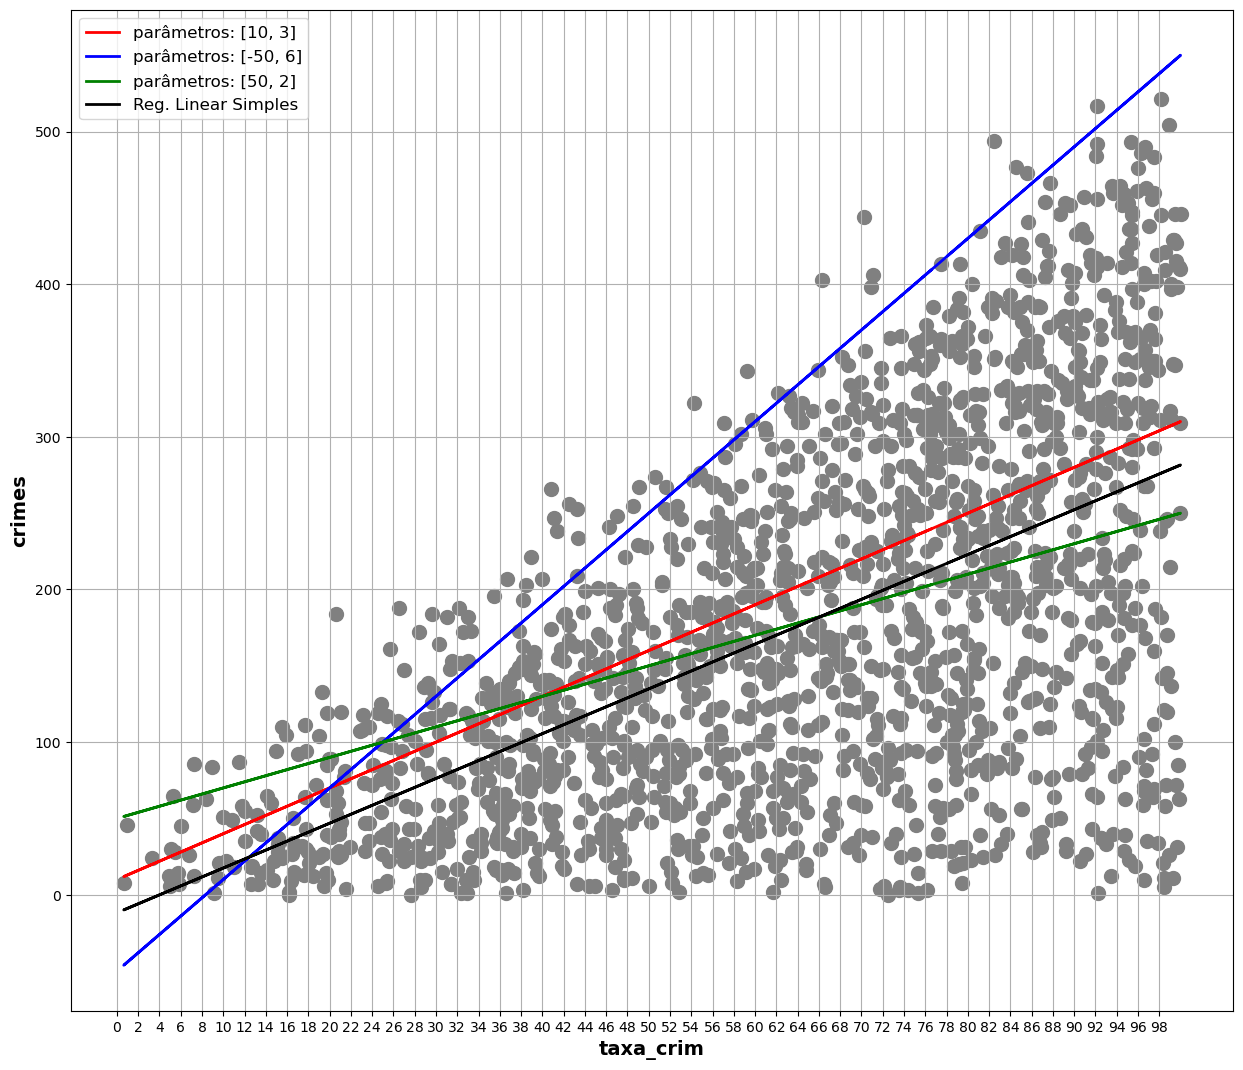

In [23]:
X = df_train['taxa_crim']
y1 = funcao_linear(X, theta0 = 10, theta1 = 3)  
y2 = funcao_linear(X, theta0 = -50, theta1 = 6)  
y3 = funcao_linear(X, theta0 = 50, theta1 = 2)


plt.figure(figsize=[15,13])
plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
plt.xlabel("taxa_crim", fontweight = 'bold', fontsize = 14)
plt.ylabel("crimes", fontweight = 'bold', fontsize = 14)
plt.xticks(range(0,100,2))
plt.grid()


plt.plot(X, y1, label = 'parâmetros: [10, 3]', lw = 2, c = 'red')
plt.plot(X, y2, label = 'parâmetros: [-50, 6]', lw = 2, c = 'blue')
plt.plot(X, y3, label = 'parâmetros: [50, 2]', lw = 2, c = 'green')
plt.plot(X, ypred, c = 'black', lw = 2, label = 'Reg. Linear Simples')
plt.legend(fontsize = 12)
plt.show()

In [24]:
lm.intercept_,lm.coef_

(array([-11.79530073]), array([[2.93373072]]))

In [25]:
from sklearn.neighbors import KNeighborsRegressor

In [27]:
df_train.head()

,ind_pop_cid,perc_pol,taxa_crim,nivel_ed,crimes
1920,1.0,21.350132,78.139691,10.0,131
1116,5.0,1.629706,96.323158,3.0,486
724,5.0,26.266499,79.611255,8.0,121
1772,4.0,25.330314,76.945102,6.0,138
2166,2.0,12.169582,75.959379,8.0,139


In [66]:
X = df_train[['ind_pop_cid','perc_pol','taxa_crim','nivel_ed']].values
y = df_train.crimes.values

type(X), X.shape

(numpy.ndarray, (1722, 4))

In [67]:
knn = KNeighborsRegressor(n_neighbors= 3)

In [68]:
knn.fit(X,y)

KNeighborsRegressor(n_neighbors=3)

In [69]:
Crimes = np.array([[4.0, 25.0, 54.0, 7.0]])

In [70]:
knn.predict(Crimes)

array([27.33333333])

In [71]:
for num_vizinhos in range(1,10):
    
    knn = KNeighborsRegressor(n_neighbors = num_vizinhos)
    knn.fit(X, y)
    pred__ = knn.predict(Crimes)[0]
    
    print("Número de vizinhos: ", num_vizinhos, " crimes estimado: ", pred__)

Número de vizinhos:  1  crimes estimado:  36.0
Número de vizinhos:  2  crimes estimado:  25.0
Número de vizinhos:  3  crimes estimado:  27.333333333333332
Número de vizinhos:  4  crimes estimado:  50.75
Número de vizinhos:  5  crimes estimado:  56.4
Número de vizinhos:  6  crimes estimado:  52.0
Número de vizinhos:  7  crimes estimado:  52.714285714285715
Número de vizinhos:  8  crimes estimado:  47.75
Número de vizinhos:  9  crimes estimado:  48.44444444444444


In [72]:
X = df_train[['ind_pop_cid','perc_pol','taxa_crim','nivel_ed']].values
y = df_train.crimes.values

In [73]:
knn = KNeighborsRegressor(n_neighbors = 5)
knn.fit(X , y)
print("RMSE do KNN com 5 vizinhos: ", RMSE(y = y, y_pred = knn.predict(X)))

RMSE do KNN com 5 vizinhos:  28.466177334382646


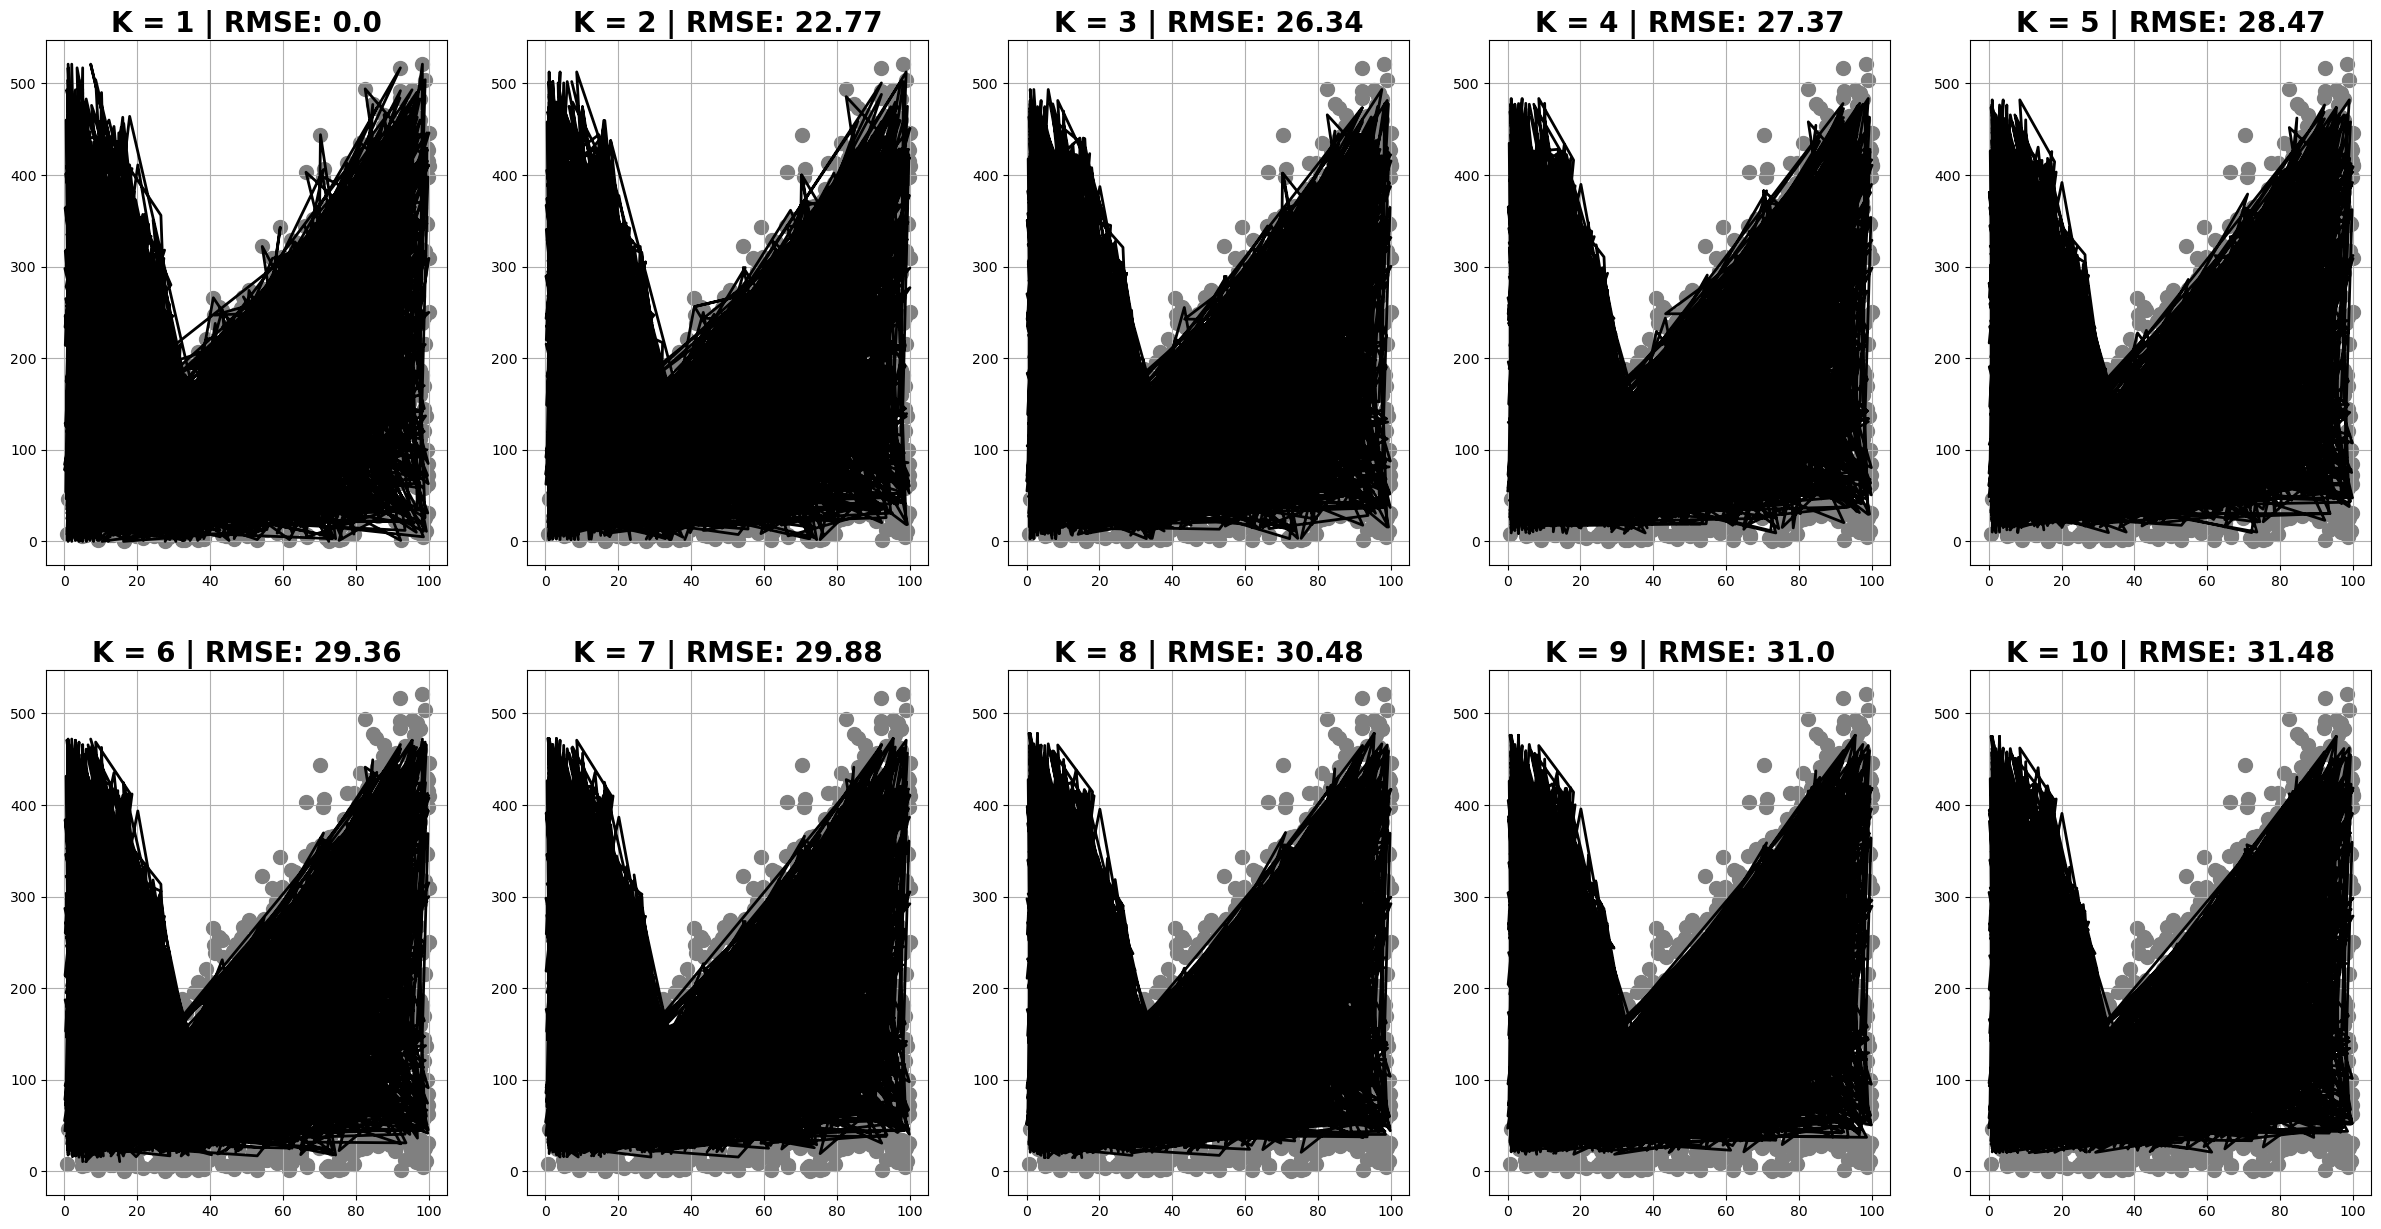

In [80]:
plt.figure(figsize=[30,15])

for i in range(1, 11):
    knn = KNeighborsRegressor(n_neighbors = i).fit(X, y)
    rmse_knn = np.round(RMSE(y = y, y_pred = knn.predict(X)), 2)
    
    plt.subplot(2,5,i)
    plt.title("K = "+str(i)+" | RMSE: " + str(rmse_knn), fontsize = 20, fontweight = 'bold')
    plt.plot(X, knn.predict(X), c = 'black', lw = 2)
    plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
    plt.grid()

plt.show()

In [81]:
df_test.head()

,ind_pop_cid,perc_pol,taxa_crim,nivel_ed,crimes
1221,3.0,18.699115,97.997106,8.0,285
380,4.0,6.913945,98.920959,4.0,454
31,1.0,4.319841,38.783139,2.0,151
187,5.0,10.627313,45.814331,9.0,106
644,3.0,35.178324,71.965770,1.0,25


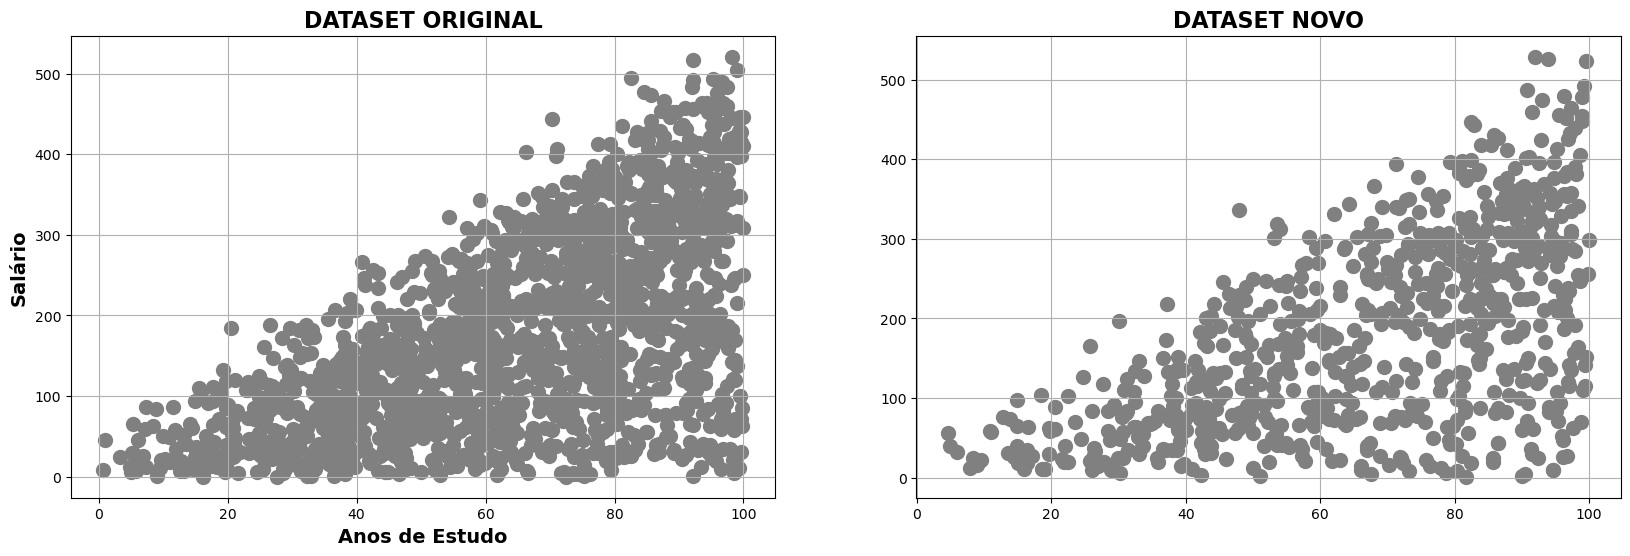

In [82]:
plt.figure(figsize=[20,6])
plt.subplot(1,2,1)
plt.title("DATASET ORIGINAL", fontsize = 16, fontweight = 'bold')
plt.scatter(df_train['taxa_crim'], df_train['crimes'], s = 100, c = 'gray')
plt.grid()
plt.xlabel("Anos de Estudo", fontsize = 14, fontweight = 'bold')
plt.ylabel("Salário", fontsize = 14, fontweight = 'bold')
plt.subplot(1,2,2)
plt.title("DATASET NOVO", fontsize = 16, fontweight = 'bold')
plt.scatter(df_test['taxa_crim'], df_test['crimes'], s = 100, c = 'gray')
plt.grid()
plt.show()

In [83]:
def plota_curva_regressao(X, y, Xnovo, ynovo, modelo, nome_modelo):
    
    modelo.fit(X, y)
    
    predicao_dataset_treino = modelo.predict(X)
    predicao_dataset_novo = modelo.predict(Xnovo)
    
    rmse_dataset_treino = np.round(RMSE(y = y, y_pred = predicao_dataset_treino), 2)
    rmse_dataset_novo = np.round(RMSE(y = ynovo, y_pred = predicao_dataset_novo), 2)
    
    plt.figure(figsize = [20,6])
    plt.subplot(1,2,1)
    plt.title("Modelo: " + nome_modelo + " ~ RMSE DATASET TREINO: " + str(rmse_dataset_treino),
              fontsize = 14, fontweight = 'bold')
    plt.scatter(X, y, c = 'gray', s = 100)
    plt.plot(X, predicao_dataset_treino, c = 'blue', lw = 2, label = 'predição ')
    plt.legend(fontsize = 14)
    plt.grid()
    plt.subplot(1,2,2)
    plt.title("Modelo: " + nome_modelo + " ~ RMSE DATASET NOVO: " + str(rmse_dataset_novo),
              fontsize = 14, fontweight = 'bold')
    plt.scatter(Xnovo, ynovo, c = 'gray', s = 100)
    plt.plot(Xnovo, predicao_dataset_novo, c = 'blue', lw = 2, label = 'predição ')
    plt.legend(fontsize = 14)
    plt.grid()
    plt.show()

In [91]:
X = df_train['taxa_crim'].values.reshape(-1,1)
y = df_train.crimes.values
Xnovo = df_test['taxa_crim'].values.reshape(-1,1)
ynovo = df_test.crimes.values

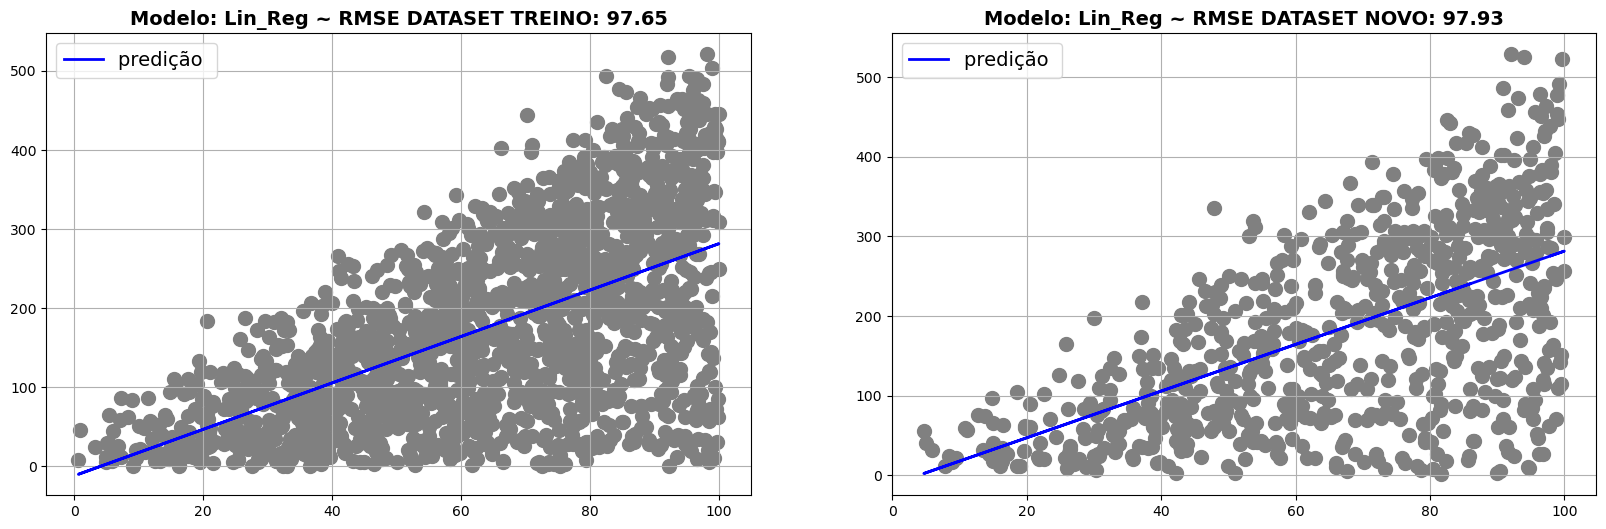

In [92]:
modelo = LinearRegression()
nome_modelo = 'Lin_Reg'
plota_curva_regressao(X, y, Xnovo, ynovo, modelo, nome_modelo)

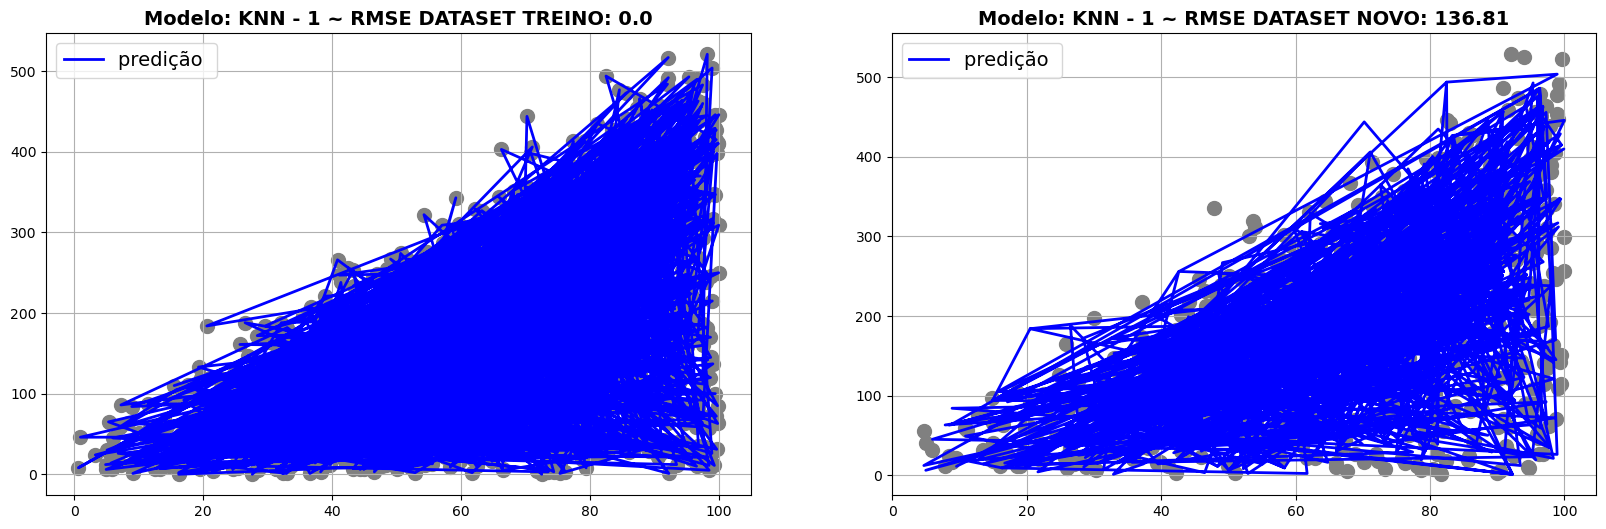

In [93]:
modelo = KNeighborsRegressor(n_neighbors = 1)
nome_modelo = 'KNN - 1'
plota_curva_regressao(X, y, Xnovo, ynovo, modelo, nome_modelo)

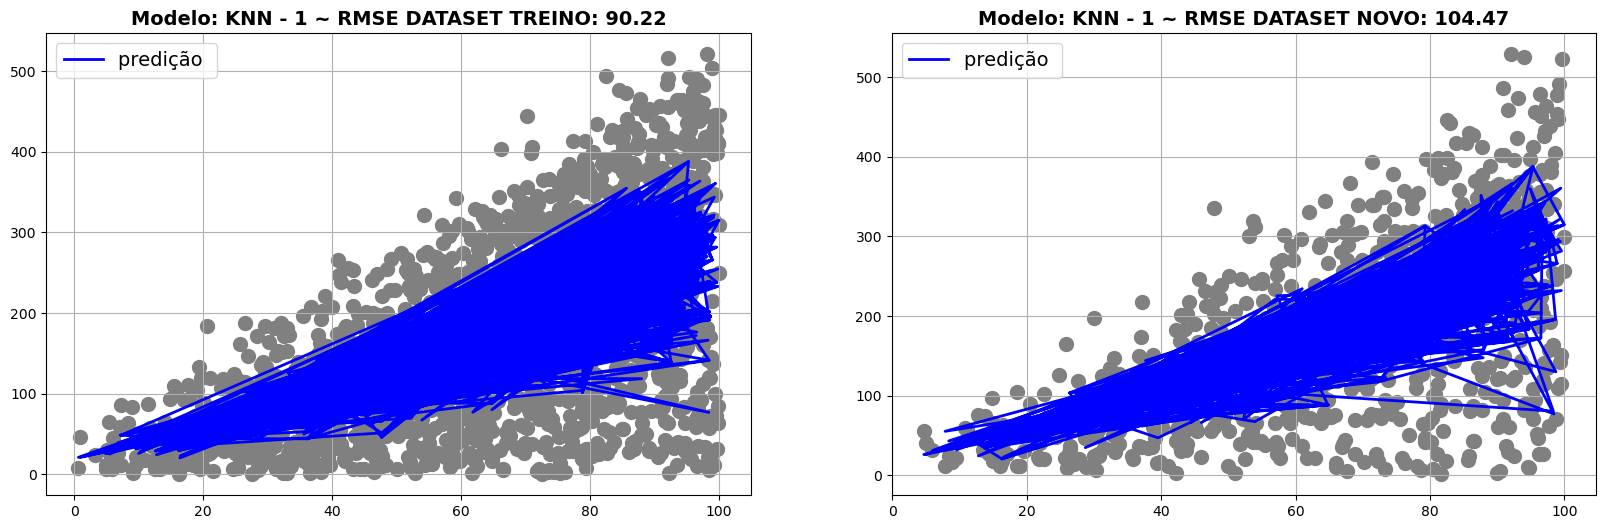

In [95]:
modelo = KNeighborsRegressor(n_neighbors = 6)
nome_modelo = 'KNN - 1'
plota_curva_regressao(X, y, Xnovo, ynovo, modelo, nome_modelo)

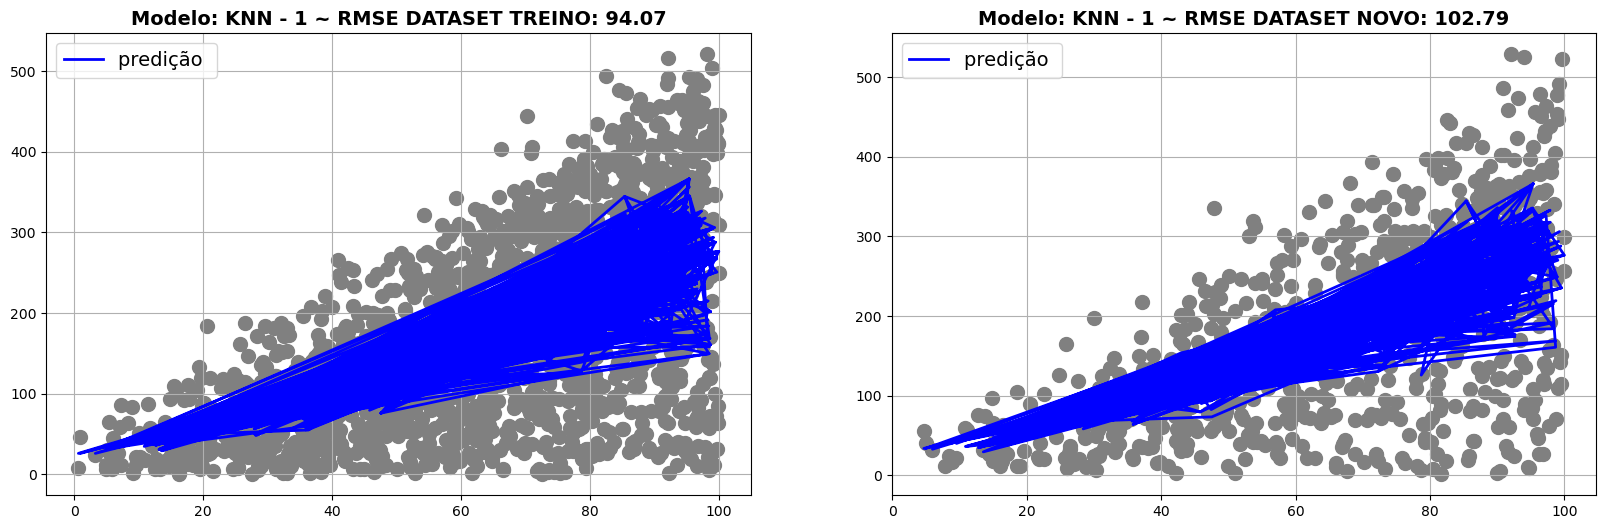

In [97]:
modelo = KNeighborsRegressor(n_neighbors = 12)
nome_modelo = 'KNN - 1'
plota_curva_regressao(X, y, Xnovo, ynovo, modelo, nome_modelo)